<a href="https://colab.research.google.com/github/HelalaAShehri/MA-MSCNet-BrainTumor/blob/main/MA_MSCNet_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MA-MSCNet: Explainable Brain Tumor Classification Demo

This notebook provides a reproducible demonstration of the MA-MSCNet framework for multi-class brain tumor classification using MRI images.

The demo focuses on:
- Model inference using a pretrained network
- Visual explanation through Grad-CAM
- Feature-level interpretation using morphology-aware components

The goal is to provide a lightweight and interpretable demonstration of the model behavior without requiring access to the full training pipeline.

## 1. Install Dependencies

This section installs the minimal set of libraries required to run the demo.  
The environment is kept lightweight to ensure easy reproducibility in Google Colab.

In [44]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## 2. Import Required Libraries

We import the core libraries used for:
- Image processing (OpenCV)
- Numerical computation (NumPy)
- Deep learning (TensorFlow/Keras)
- Visualization (Matplotlib)

In [45]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.utils import register_keras_serializable
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt




## 3. Define Custom Morphological Layers

The MA-MSCNet architecture includes custom trainable morphological operators:
- MorphoDilate
- MorphoErode

These layers are required when loading the pretrained model to ensure proper reconstruction of the architecture.

Note: These implementations match the layers used during model training.

In [46]:


# ============================================================
# Trainable Morphological Layers
# ============================================================

@register_keras_serializable()
class MorphoDilate(Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.kernel = self.add_weight(
            name="dilate_kernel",
            shape=(1,1,1,channels),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, x):
        x_shifted = x + self.kernel
        return tf.nn.max_pool(
            x_shifted,
            ksize=[1,self.kernel_size,self.kernel_size,1],
            strides=[1,1,1,1],
            padding="SAME"
        )


@register_keras_serializable()
class MorphoErode(Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.kernel = self.add_weight(
            name="erode_kernel",
            shape=(1,1,1,channels),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, x):
        x_shifted = x - self.kernel
        return -tf.nn.max_pool(
            -x_shifted,
            ksize=[1,self.kernel_size,self.kernel_size,1],
            strides=[1,1,1,1],
            padding="SAME"
        )


## 4. Load Pretrained MA-MSCNet Model

The pretrained model is hosted externally due to GitHub file size limitations.  
It is automatically downloaded from Google Drive when running this notebook.

This ensures:
- Reproducibility
- Ease of use
- No manual setup required

In [47]:
# ============================================================
# Download pretrained MA-MSCNet model from Google Drive
# ============================================================

!pip -q install gdown

import os
import gdown

MODEL_PATH = "final_MSCNeT_after_cv.h5"
FILE_ID = "1QkLMZq_hRj6EQSijG8qxURAAysKXcYPi"

if not os.path.exists(MODEL_PATH):
    print("Downloading model...")
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        MODEL_PATH,
        quiet=False
    )
else:
    print("Model already exists.")



Model already exists.


## 5. Load Model

The pretrained MA-MSCNet model is loaded along with the custom morphological layers.

This model was trained on grayscale MRI images resized to 125×125 and normalized to [0,1].

In [48]:
# ============================================================
# Load model
# ============================================================
custom_objects = {
    "MorphoDilate": MorphoDilate,
    "MorphoErode": MorphoErode
}

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects=custom_objects
)

## 6. Image Preprocessing

To ensure consistency with training, input images are:
- Converted to grayscale
- Resized to 125×125
- Normalized to [0,1]
- Reshaped to (125, 125, 1)

Maintaining identical preprocessing is critical for reliable predictions.

In [77]:


image_size = 125

# Must match training-time label order
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def load_single_image(image_path, image_size=125):
    image_size = 125

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    image = cv2.resize(image, (image_size, image_size))
    image = image / 255.0
    image = np.expand_dims(image, axis=-1)   # (125,125,1)
    image = np.expand_dims(image, axis=0)    # (1,125,125,1)

    return image.astype(np.float32)

def predict_single_image(model, image_path, class_names):
    x = load_single_image(image_path, image_size=image_size)
    pred = model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(pred)

    print("Image path:", image_path)
    print("Predicted class:", class_names[pred_idx])
    print("Confidence:", float(pred[pred_idx]))
    print("All probabilities:")
    for cls, score in zip(class_names, pred):
        print(f"{cls}: {score:.4f}")

    return pred_idx, pred

## Helper function

This section defines a set of utility functions used to support visualization and analysis within the notebook. These functions are designed to simplify common operations such as normalization, feature selection, and image formatting.



In [76]:


# ============================================================
# 1) Choose the target block
# ============================================================
target_block = "block2"   # or "block3"

dil_layer_name = f"{target_block}_inblock_dilate"
ero_layer_name = f"{target_block}_inblock_erode"

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=[
        model.get_layer(dil_layer_name).output,
        model.get_layer(ero_layer_name).output
    ]
)

# ============================================================
# 2) Image loading function
# ============================================================
image_size = 125

def load_single_image(image_path, image_size=125):
    image_size = 125

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    image = cv2.resize(image, (image_size, image_size))
    image = image / 255.0
    image = np.expand_dims(image, axis=-1)   # (125, 125, 1)
    image = np.expand_dims(image, axis=0)    # (1, 125, 125, 1)

    return image.astype(np.float32)

# ============================================================
# 3) Helper functions
# ============================================================
def normalize_map(fmap):
    fmap = fmap.astype(np.float32)
    mn, mx = np.min(fmap), np.max(fmap)
    if mx - mn < 1e-8:
        return np.zeros_like(fmap)
    return (fmap - mn) / (mx - mn)

def pick_representative_channels(feat, top_k=3, method="variance"):
    """
    feat shape = (H, W, C)
    """
    C = feat.shape[-1]

    if method == "variance":
        scores = np.array([np.var(feat[:, :, i]) for i in range(C)])
    elif method == "mean":
        scores = np.array([np.mean(np.abs(feat[:, :, i])) for i in range(C)])
    else:
        return np.arange(min(top_k, C))

    idx = np.argsort(scores)[::-1][:top_k]
    return idx

def plot_publication_feature_maps(
    input_img,
    dil_feat,
    ero_feat,
    dil_idx,
    ero_idx,
    save_path=None,
    sample_title=None
):
    """
    Layout:
    Row 1: Input | Dil-1 | Dil-2 | Dil-3
    Row 2: blank | Ero-1 | Ero-2 | Ero-3
    """
    if input_img.ndim == 3 and input_img.shape[-1] == 1:
        input_img = input_img[:, :, 0]

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    axes[0, 0].imshow(input_img, cmap="gray")
    axes[0, 0].set_title("Input MRI", fontsize=13)
    axes[0, 0].axis("off")

    for j in range(3):
        fmap = normalize_map(dil_feat[:, :, dil_idx[j]])
        axes[0, j + 1].imshow(fmap, cmap="gray")
        axes[0, j + 1].set_title(f"Dil (Map {j+1})", fontsize=13)
        axes[0, j + 1].axis("off")

    axes[1, 0].axis("off")

    for j in range(3):
        fmap = normalize_map(ero_feat[:, :, ero_idx[j]])
        axes[1, j + 1].imshow(fmap, cmap="gray")
        axes[1, j + 1].set_title(f"Ero (Map {j+1})", fontsize=13)
        axes[1, j + 1].axis("off")

    if sample_title is not None:
        fig.suptitle(sample_title, fontsize=14, y=0.98)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

In [74]:
def visualize_feature_maps_from_path(model, image_path, target_block="block2", image_size=125):
    dil_layer_name = f"{target_block}_inblock_dilate"
    ero_layer_name = f"{target_block}_inblock_erode"

    feature_model = tf.keras.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(dil_layer_name).output,
            model.get_layer(ero_layer_name).output
        ]
    )

    x = load_single_image(image_path, image_size=image_size)
    dil_out, ero_out = feature_model.predict(x, verbose=0)
    dil_out, ero_out = dil_out[0], ero_out[0]

    dil_idx = pick_representative_channels(dil_out, top_k=3, method="variance")
    ero_idx = pick_representative_channels(ero_out, top_k=3, method="variance")

    img_name = os.path.splitext(os.path.basename(image_path))[0]
    save_path = f"{target_block}_{img_name}_featuremaps_publication.png"

    plot_publication_feature_maps(
        input_img=x[0],
        dil_feat=dil_out,
        ero_feat=ero_out,
        dil_idx=dil_idx,
        ero_idx=ero_idx,
        save_path=save_path,
        sample_title=f"Representative Dil and Ero Feature Maps ({target_block})"
    )

In [73]:


# ============================================================
# 2) Visual helpers
# ============================================================
def normalize_grayscale_percentile(img, p1=1, p99=99):
    if img.ndim == 3:
        img = img[..., 0]
    x = img.astype(np.float32)
    x = np.clip(x, 0.0, 1.0)
    lo, hi = np.percentile(x, [p1, p99])
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0.0, 1.0)
    return (x * 255).astype(np.uint8)

def make_brain_mask(gray_u8, thresh=10):
    m = (gray_u8 > thresh).astype(np.uint8) * 255
    m = cv2.medianBlur(m, 5)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    return (m > 0).astype(np.float32)

def smooth_heatmap(hm, ksize=5, sigma=1.0):
    hm_u8 = np.clip(hm * 255.0, 0, 255).astype(np.uint8)
    hm_blur = cv2.GaussianBlur(hm_u8, (ksize, ksize), sigma)
    hm = hm_blur.astype(np.float32) / 255.0
    hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
    return hm

def combo_grayscale_and_overlay(gray_u8, heatmap01, alpha=0.38, colormap=cv2.COLORMAP_JET):
    gray_rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2RGB)
    heat_u8 = np.clip(heatmap01 * 255.0, 0, 255).astype(np.uint8)
    heat_bgr = cv2.applyColorMap(heat_u8, colormap)
    heat_rgb = cv2.cvtColor(heat_bgr, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.addWeighted(gray_rgb, 1.0 - alpha, heat_rgb, alpha, 0)
    combo = np.concatenate([gray_rgb, overlay_rgb], axis=1)
    return combo

# ============================================================
# 3) Handle named input / list output
# ============================================================
def get_prediction_tensor(preds):
    if isinstance(preds, (list, tuple)):
        preds = preds[-1]
    return preds

# ============================================================
# 4) Grad-CAM
# ============================================================
def make_gradcam_heatmap(model, img, class_index=None, target_layer_name="block4_relu"):
    target_layer = model.get_layer(target_layer_name)
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.outputs]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model({"mri_input": img}, training=False)
        preds = get_prediction_tensor(preds)

        if class_index is None:
            class_index = int(tf.argmax(preds[0]).numpy())

        score = preds[:, class_index]

    grads = tape.gradient(score, conv_out)
    conv_out = conv_out[0]
    grads = grads[0]

    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.reduce_sum(conv_out * weights, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    heatmap = cv2.resize(cam.numpy(), (image_size, image_size))
    return heatmap, preds[0].numpy(), class_index

# ============================================================
# 5) Single-image Grad-CAM grid
# ============================================================
def visualize_single_image_gradcam_grid(
    model,
    image_path,
    class_names,
    target_layer_name="block4_relu",
    alpha=0.38,
    use_mask=True,
    mask_thresh=10,
    use_heatmap_smoothing=True,
    smooth_ksize=5,
    smooth_sigma=1.0,
    save_path=None
):
    x = load_single_image(image_path)
    gray_u8 = normalize_grayscale_percentile(x[0])

    heatmap, probs, pred_idx = make_gradcam_heatmap(
        model=model,
        img=x,
        class_index=None,
        target_layer_name=target_layer_name
    )

    if use_heatmap_smoothing:
        heatmap = smooth_heatmap(heatmap, ksize=smooth_ksize, sigma=smooth_sigma)

    if use_mask:
        mask = make_brain_mask(gray_u8, thresh=mask_thresh)
        heatmap = heatmap * mask
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    combo = combo_grayscale_and_overlay(gray_u8, heatmap, alpha=alpha)

    plt.figure(figsize=(8, 4))
    plt.imshow(combo)
    plt.title(f"{class_names[pred_idx]} | P={probs[pred_idx]:.2f}")
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return pred_idx, probs, heatmap

## Single Image Prediction

This section demonstrates how to perform inference on a single MRI image.

The model outputs:
- Predicted tumor class
- Confidence score
- Class probability distribution

In [78]:
img_path = '/content/drive/MyDrive/Datasets/Tumor/Testing/meningioma/Te-me_0172.jpg'
#img_path = '../sample_images/glioma_01.jpg'

predict_single_image(model, img_path, class_names)

Image path: /content/drive/MyDrive/Datasets/Tumor/Testing/meningioma/Te-me_0172.jpg
Predicted class: meningioma
Confidence: 0.9305174946784973
All probabilities:
glioma: 0.0228
meningioma: 0.9305
notumor: 0.0230
pituitary: 0.0237


(np.int64(1),
 array([0.02279687, 0.9305175 , 0.02295525, 0.0237304 ], dtype=float32))

##  Feature Map Visualization (Morphological Operators)

To further illustrate the behavior of the proposed morphology-aware components, this section visualizes representative feature maps produced by the trainable dilation and erosion layers.

Specifically:
- Dilation maps emphasize prominent structural responses
- Erosion maps highlight boundary-related patterns and suppress irrelevant activations

For clarity, a subset of representative channels is selected based on statistical criteria (e.g., variance), allowing meaningful interpretation without overwhelming visualization.

This analysis provides qualitative insight into how the model refines features using morphological operations.

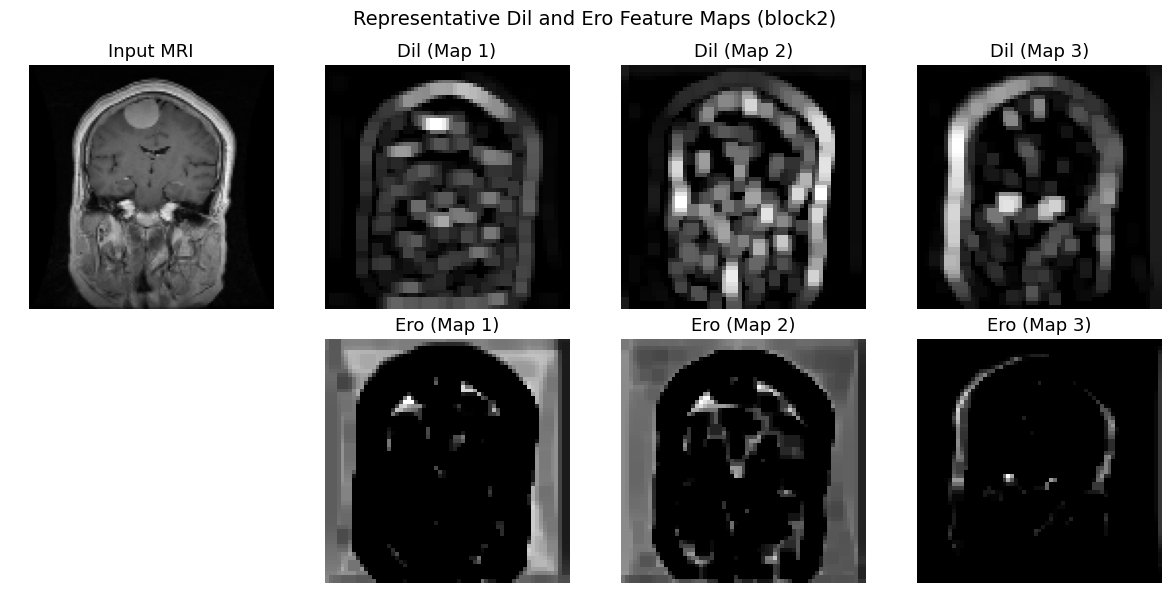

In [79]:
visualize_feature_maps_from_path(
    model,
    img_path,
    target_block="block2"
)

## Grad-CAM Visualization

Grad-CAM is used to provide visual explanations for the model predictions.

It highlights regions of the MRI image that contribute most to the classification decision, improving interpretability and trust in the model.

This is particularly important in medical imaging applications.

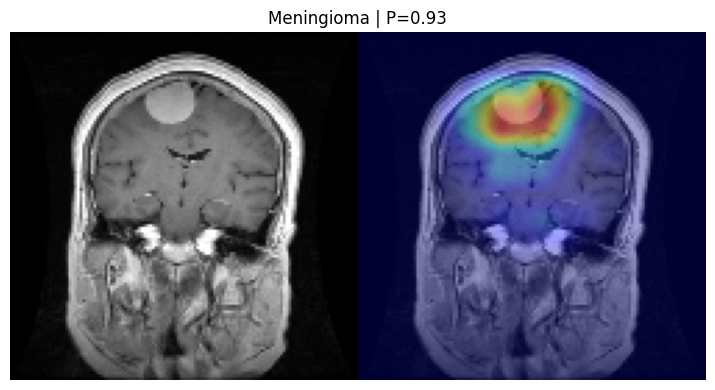

In [80]:
class_names = ["Glioma", "Meningioma", "Notumor", "Pituitary"]
#image_path = "/content/drive/MyDrive/Datasets/Tumor/Testing/glioma/Te-gl_0010.jpg"
img_path = '/content/drive/MyDrive/Datasets/Tumor/Testing/meningioma/Te-me_0172.jpg'

pred_idx, probs, heatmap = visualize_single_image_gradcam_grid(
    model=model,
    image_path=img_path,
    class_names=class_names,
    target_layer_name="block4_relu",
    save_path="single_image_gradcam_grid.png"
)

## Optional: Upload Your Own MRI Image

In addition to the provided sample images, you may upload a custom MRI image directly from your local machine and run the same inference and Grad-CAM pipeline used throughout this notebook.

The uploaded image will be:
- converted to grayscale,
- resized to 125 × 125,
- normalized to the range [0, 1], and
- processed using the pretrained MA-MSCNet model.

This allows interactive testing of the model on new images while preserving consistency with the original preprocessing workflow.

Please upload an MRI image file...


Saving glioma_01.jpg to glioma_01.jpg
Uploaded file: glioma_01.jpg


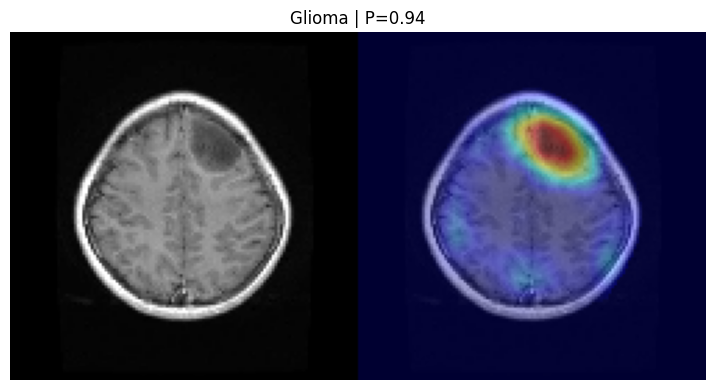

Predicted class: Glioma
Confidence: 93.76%
Saved Grad-CAM figure to: /content/single_image_gradcam_grid.png


In [72]:
# ============================================================
# Optional: Upload your own MRI image from local machine
# and run the same Grad-CAM pipeline
# ============================================================

from google.colab import files
import os

print("Please upload an MRI image file...")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file was uploaded.")

img_path = list(uploaded.keys())[0]
print("Uploaded file:", img_path)

pred_idx, probs, heatmap = visualize_single_image_gradcam_grid(
    model=model,
    image_path=img_path,
    class_names=class_names,
    target_layer_name="block4_relu",
    save_path="single_image_gradcam_grid.png"
)

print(f"Predicted class: {class_names[pred_idx]}")
print(f"Confidence: {probs[pred_idx]*100:.2f}%")
print("Saved Grad-CAM figure to:", os.path.abspath("single_image_gradcam_grid.png"))

## Notes

- This notebook provides an inference-focused implementation of MA-MSCNet.
- Full training scripts and experimental pipelines are not included.
- The dataset used is publicly available.
- All results shown here are reproducible using the provided pretrained model.

The design prioritizes clarity, usability, and interpretability.